In [1]:
from torchvision.models import resnet18
from torch import nn
import torch
from torch import optim
from matplotlib import pyplot as plt
from torchvision import transforms
from torchvision.datasets import CIFAR100
from torch.utils.data import DataLoader
from tqdm import tqdm
from torch.utils.tensorboard import SummaryWriter
device = "cuda" if torch.cuda.is_available() else 'cpu'
writer = SummaryWriter(log_dir='runs')

In [2]:
mean = torch.tensor([0.5071, 0.4867, 0.4408])
std = torch.tensor([0.2675, 0.2565, 0.2761])

In [3]:
device

'cuda'

In [4]:

ttransforms = transforms.Compose([
    # 1. Pad the image and take a random crop
    transforms.RandomCrop(32, padding=4), 
    
    # 2. Flip horizontally
    transforms.RandomHorizontalFlip(),

    
    # 3. Convert to tensor
    transforms.ToTensor(), 
    
    # 4. Normalize the data
    transforms.Normalize(mean=mean, std=std),
    transforms.RandomErasing(p=0.5, scale=(0.02, 0.33), ratio=(0.3, 3.3)),
])

testf = transforms.Compose([transforms.ToTensor(),
                              transforms.Normalize(mean=mean, std=std)])


In [5]:
train_data = CIFAR100(root='data',
                      train=True,
                      download=True,
                      transform=ttransforms)
test_data = CIFAR100(root='data',
                     train=False,
                     download=True,
                     transform=testf)

In [6]:
classes = test_data.classes
classes

['apple',
 'aquarium_fish',
 'baby',
 'bear',
 'beaver',
 'bed',
 'bee',
 'beetle',
 'bicycle',
 'bottle',
 'bowl',
 'boy',
 'bridge',
 'bus',
 'butterfly',
 'camel',
 'can',
 'castle',
 'caterpillar',
 'cattle',
 'chair',
 'chimpanzee',
 'clock',
 'cloud',
 'cockroach',
 'couch',
 'crab',
 'crocodile',
 'cup',
 'dinosaur',
 'dolphin',
 'elephant',
 'flatfish',
 'forest',
 'fox',
 'girl',
 'hamster',
 'house',
 'kangaroo',
 'keyboard',
 'lamp',
 'lawn_mower',
 'leopard',
 'lion',
 'lizard',
 'lobster',
 'man',
 'maple_tree',
 'motorcycle',
 'mountain',
 'mouse',
 'mushroom',
 'oak_tree',
 'orange',
 'orchid',
 'otter',
 'palm_tree',
 'pear',
 'pickup_truck',
 'pine_tree',
 'plain',
 'plate',
 'poppy',
 'porcupine',
 'possum',
 'rabbit',
 'raccoon',
 'ray',
 'road',
 'rocket',
 'rose',
 'sea',
 'seal',
 'shark',
 'shrew',
 'skunk',
 'skyscraper',
 'snail',
 'snake',
 'spider',
 'squirrel',
 'streetcar',
 'sunflower',
 'sweet_pepper',
 'table',
 'tank',
 'telephone',
 'television',
 'tig

In [7]:
train_dataloader = DataLoader(train_data,
                              shuffle=True,
                              batch_size=64,
                              num_workers=10)
test_dataloader = DataLoader(test_data,
                             shuffle=False,
                             batch_size=40,
                             num_workers=6)

In [8]:
# plot like 67 images
#x, y = next(iter(test_dataloader))
#img = x[0] * std + mean
#img = img.permute(1, 2, 0)
#img = img.squeeze().numpy()
#plt.title(classes[y[0].item()])
#plt.imshow(img)
#plt.axis(False)
#figure = plt.figure(figsize=(10, 10))
#for i in range(40):
#    img = x[i] * std + mean
#    img = img.permute(1, 2, 0)
#    img = img.squeeze().numpy()
#    ax = plt.subplot(10, 10, i +1)
#    plt.title(classes[y[i].item()])
#    plt.imshow(img)
#    plt.axis(False)
#x.shape

In [9]:

import torch.nn.functional as F

class BasicBlock(nn.Module):
    """simple residual basic block for small images"""
    def __init__(self, in_planes, planes, stride=1, drop_prob=0.0):
        super().__init__()
        self.conv1 = nn.Conv2d(in_planes, planes, kernel_size=3, stride=stride,
                               padding=1, bias=False)
        self.bn1 = nn.BatchNorm2d(planes)
        self.conv2 = nn.Conv2d(planes, planes, kernel_size=3, stride=1,
                               padding=1, bias=False)
        self.bn2 = nn.BatchNorm2d(planes)
        self.relu = nn.ReLU(inplace=True)
        self.drop = nn.Dropout2d(drop_prob) if drop_prob > 0 else nn.Identity()

        self.downsample = nn.Identity()
        if stride != 1 or in_planes != planes:
            # adjust residual size
            self.downsample = nn.Sequential(
                nn.Conv2d(in_planes, planes, kernel_size=1, stride=stride, bias=False),
                nn.BatchNorm2d(planes)
            )

    def forward(self, x):
        identity = self.downsample(x)

        out = self.conv1(x)
        out = self.bn1(out)
        out = self.relu(out)

        out = self.drop(out)
        out = self.conv2(out)
        out = self.bn2(out)

        out += identity
        out = self.relu(out)
        return out


class cifar100model(nn.Module):
    """
    compact ResNet-like model for CIFAR-100.
    - input: (N, 3, 32, 32)
    - output: (N, 100) logits
    args:
        num_blocks_per_stage: list/tuple of 3 ints (blocks in each stage)
        base_channels: int (channels in stage1)
        drop_prob: float dropout after first conv-blocks
        num_classes: int (default 100)
    """
    def __init__(self,
                 num_blocks_per_stage=(2, 2, 2),
                 base_channels=64,
                 drop_prob=0.0,
                 num_classes=100):
        super().__init__()
        assert len(num_blocks_per_stage) == 3, "expect 3 stages for CIFAR-style network"

        self.stem = nn.Sequential(
            nn.Conv2d(3, base_channels, kernel_size=3, stride=1, padding=1, bias=False),
            nn.BatchNorm2d(base_channels),
            nn.ReLU(inplace=True)
        )

        in_planes = base_channels
        self.stage1 = self._make_stage(in_planes, base_channels, num_blocks_per_stage[0], stride=1, drop_prob=drop_prob)
        in_planes = base_channels
        self.stage2 = self._make_stage(in_planes, base_channels*2, num_blocks_per_stage[1], stride=2, drop_prob=drop_prob)
        in_planes = base_channels*2
        self.stage3 = self._make_stage(in_planes, base_channels*4, num_blocks_per_stage[2], stride=2, drop_prob=drop_prob)

        final_planes = base_channels * 4
        # global pooling then fc
        self.pool = nn.AdaptiveAvgPool2d((1,1))
        self.fc = nn.Linear(final_planes, num_classes)

        # weight init
        self._init_weights()

    def _make_stage(self, in_planes, out_planes, blocks, stride, drop_prob):
        layers = []
        layers.append(BasicBlock(in_planes, out_planes, stride=stride, drop_prob=drop_prob))
        for _ in range(1, blocks):
            layers.append(BasicBlock(out_planes, out_planes, stride=1, drop_prob=drop_prob))
        return nn.Sequential(*layers)

    def _init_weights(self):
        for m in self.modules():
            if isinstance(m, nn.Conv2d):
                nn.init.kaiming_normal_(m.weight, nonlinearity='relu')
            elif isinstance(m, (nn.Linear,)):
                nn.init.xavier_uniform_(m.weight)
                if m.bias is not None:
                    nn.init.zeros_(m.bias)
            elif isinstance(m, nn.BatchNorm2d):
                nn.init.ones_(m.weight)
                nn.init.zeros_(m.bias)

    def forward(self, x):
        x = self.stem(x)         # (N, base, 32, 32)
        x = self.stage1(x)       # (N, base, 32, 32)
        x = self.stage2(x)       # (N, base*2, 16, 16)
        x = self.stage3(x)       # (N, base*4, 8, 8)
        x = self.pool(x)         # (N, base*4, 1, 1)
        x = torch.flatten(x, 1)  # (N, base*4)
        logits = self.fc(x)      # (N, num_classes)
        return logits
model = cifar100model().to(device)

In [10]:
model1 = resnet18(pretrained=True)
for n, p in model1.named_parameters():
    if 'layer3' in n or 'layer4' in n or 'fc' in n:
        p.requires_grad = True
    else:
        p.requires_grad = False
model1.to(device)
model1.fc = nn.Linear(model1.fc.in_features, 100)

/home/sam/ml_worl/lib/python3.11/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/home/sam/ml_worl/lib/python3.11/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


In [11]:
criterion = nn.CrossEntropyLoss()
STEPS_PER_EPOCH = len(train_dataloader)
optimizer = optim.Adam(model.parameters(), lr=1e-3, weight_decay=5e-4)

scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=100 * STEPS_PER_EPOCH)

In [12]:
def evaluate_model(model, loader, device):
    """Calculates the accuracy of the model on the test/validation set."""
    model.eval() # Set model to evaluation mode
    correct = 0
    total = 0
    with torch.no_grad():
        for inputs, targets in loader:
            inputs, targets = inputs.to(device), targets.to(device)
            outputs = model(inputs)
            _, predicted = outputs.max(1)
            total += targets.size(0)
            correct += predicted.eq(targets).sum().item()
    
    accuracy = 100. * correct / total
    return accuracy

# --- 6. TRAINING LOOP ---
def train_model(model, train_loader, test_loader, criterion, optimizer, scheduler, num_epochs, device):
    best_acc = 0.0
    print(f"Starting training on {device}...")

    for epoch in range(num_epochs):
        model.train() # Set model to training mode
        train_loss = 0
        correct = 0
        total = 0
        
        # Use tqdm for a nice progress bar
        train_bar = tqdm(train_loader, desc=f"Epoch {epoch+1}/{num_epochs}")
        
        for batch_idx, (inputs, targets) in enumerate(train_bar):
            inputs, targets = inputs.to(device), targets.to(device)
            
            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, targets)
            loss.backward()
            optimizer.step()
            
            # Step the scheduler *per batch* (recommended for CosineAnnealingLR)
            scheduler.step() 

            train_loss += loss.item()
            _, predicted = outputs.max(1)
            total += targets.size(0)
            correct += predicted.eq(targets).sum().item()

            train_bar.set_postfix({
                'Loss': f'{train_loss/(batch_idx+1):.4f}',
                'Acc': f'{100.*correct/total:.2f}%',
                'LR': f'{optimizer.param_groups[0]["lr"]:.6f}'
            })

        # Evaluate on the test set after each epoch
        test_acc = evaluate_model(model, test_loader, device)
        print(f"Test Accuracy after Epoch {epoch+1}: {test_acc:.2f}%")
        writer.add_scalar('Epoch/acc', test_acc, epoch)
        writer.close()

        if test_acc > best_acc:
            best_acc = test_acc
            print(f"** New best model saved with accuracy: {best_acc:.2f}% **")
            # You would typically save the model checkpoint here

    print(f"\nTraining complete. Best Test Accuracy: {best_acc:.2f}%")


In [13]:
train_model(model, train_dataloader, test_dataloader, criterion, optimizer, scheduler, 2000, device)

Starting training on cuda...


Epoch 1/2000: 100%|██████████| 782/782 [00:12<00:00, 63.27it/s, Loss=3.7064, Acc=13.15%, LR=0.001000]


Test Accuracy after Epoch 1: 19.33%
** New best model saved with accuracy: 19.33% **


Epoch 2/2000: 100%|██████████| 782/782 [00:11<00:00, 66.72it/s, Loss=3.0308, Acc=24.10%, LR=0.000999]


Test Accuracy after Epoch 2: 22.69%
** New best model saved with accuracy: 22.69% **


...

Test Accuracy after Epoch 79: 73.05%


Epoch 80/2000: 100%|██████████| 782/782 [00:10<00:00, 71.61it/s, Loss=0.5194, Acc=85.13%, LR=0.000095]


Test Accuracy after Epoch 80: 73.43%


Epoch 81/2000:  57%|█████▋    | 448/782 [00:06<00:05, 64.55it/s, Loss=0.4940, Acc=85.71%, LR=0.000090]


KeyboardInterrupt: 

In [ ]:
correct = 0
total = 0
model.eval()
with torch.no_grad():
    for x, y in test_dataloader:
        x, y = x.to(device), y.to(device)
        preds = model(x)
        _, pred_labels = preds.max(1)
        correct += (pred_labels == y).sum().item()
        total += y.size(0)

print('acc:', correct / total)


acc: 0.7239


In [ ]:
model1.to(device)

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
  

In [ ]:
import pandas as pd
import seaborn as sns
df = pd.read_csv('acc_results.csv')
df.head()

,Wall time,Step,Value
0,1.762633e+09,0,16.820000
1,1.762633e+09,1,20.690001
2,1.762633e+09,2,29.670000
3,1.762633e+09,3,35.099998
4,1.762633e+09,4,42.369999


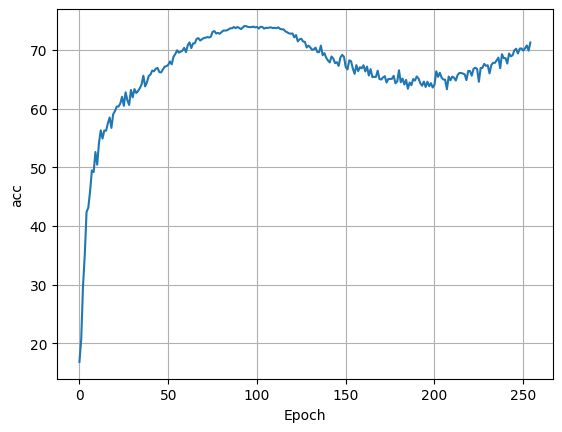

In [ ]:
sns.lineplot(data=df, x='Step', y='Value')
plt.xlabel('Epoch')
plt.ylabel('acc')
plt.grid(True)